In [22]:
!pip install statsmodels pymannkendall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 10.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 11.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.9/95.9 kB 7.2 MB/s eta 0:00:00


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, ccf
import pymannkendall as mk
import warnings

In [2]:
csv_file = "/Users/sambit_03/Desktop/Time Series Influenza/Preprocess/flu_clean.csv"
df = pd.read_csv(csv_file, parse_dates=["iso_sdate_parsed"])

In [ ]:
# Renaming the columns 
df = df.rename(columns={
    "iso_sdate_parsed": "date",
    "INF_ALL": "inf_all",
    "epidemic_threshold": "threshold"
})

In [4]:
# Sorting wrt country and dates
df = df.sort_values(["country", "date"])

In [5]:
COUNTRIES = ["USA", "UK", "India", "Japan"]
COLORS = {"USA": "#1f77b4", "UK": "#ff7f0e", "India": "#2ca02c", "Japan": "#d62728"}

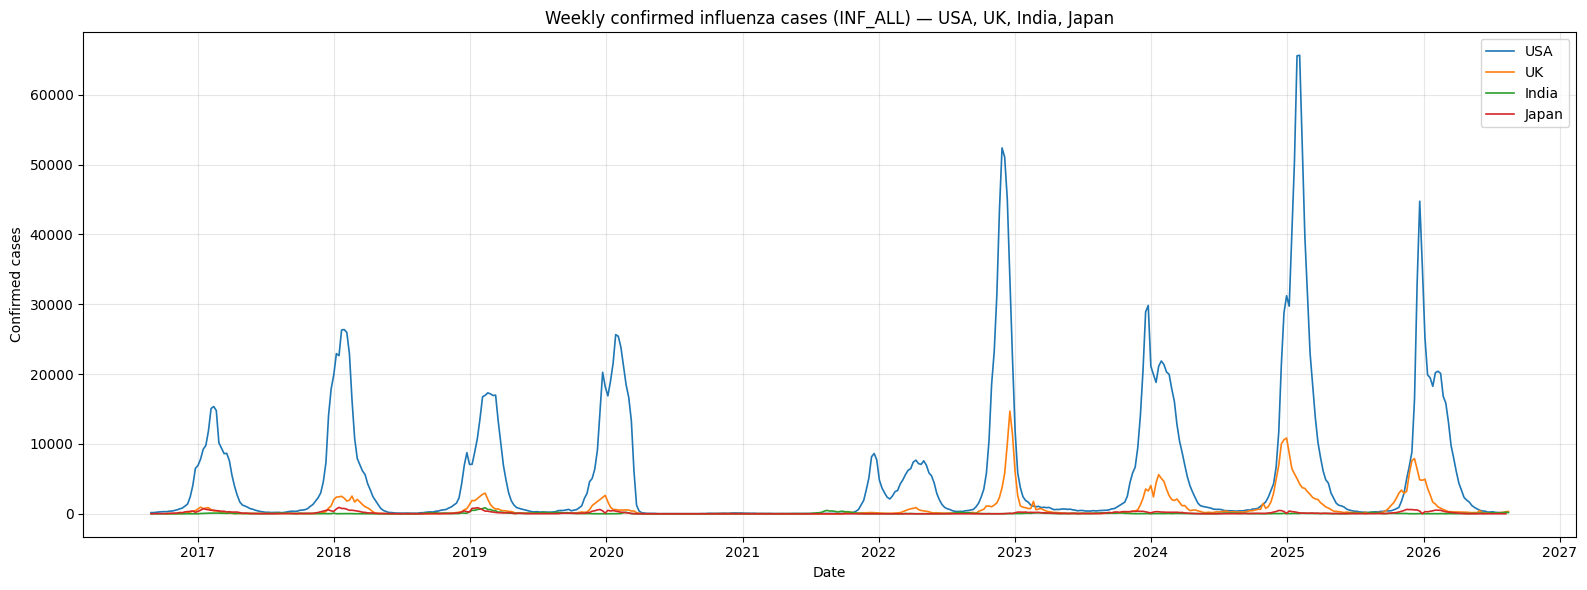

In [9]:
# Weekly spike for the influenza cases across 5 countries 
fig, ax = plt.subplots(figsize=(16, 6))
for country in COUNTRIES:
    sub = df[df["country"] == country]
    ax.plot(sub["date"], sub["inf_all"], label=country, color=COLORS[country], linewidth=1.2)

ax.set_title("Weekly confirmed influenza cases (INF_ALL) — USA, UK, India, Japan")
ax.set_xlabel("Date")
ax.set_ylabel("Confirmed cases")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("weekly_overlay_all_countries.png", dpi=150)
plt.show()

## Volumetric & Catchment Disparities:

- USA (Blue line): Dominates the absolute counts, peaking at 65,657 cases in a single week (February 2025) and maintaining an overall average of 5,662 cases/week.

- UK (Orange line): Reaches its single highest record of 14,701 cases during the post-lockdown winter surge of December 2022.

- Japan (Red line) & India (Green line): Both record much lower absolute counts (peaking at 920 and 871 cases per week, respectively). This is an artifact of surveillance catchment size and reporting protocols rather than lower actual infection rates.

## The COVID-19 Disruption Window (2020–2022):

- Across all four nations, confirmed influenza cases plummeted to near-zero levels between early 2020 and late 2021/2022.

- Non-pharmaceutical interventions (masks, social distancing, travel restrictions) suppressed normal viral circulation, interrupting the established annual baseline.

#### Post-Pandemic Resurgence ("Immunity Debt"):

- Starting late 2022, the USA and UK experienced sharp, hyper-intense winter surges that exceeded pre-2020 peak levels.

- The USA exhibited particularly high amplitude spikes during the 2022–2023, 2023–2024, and 2024–2025 winter seasons.

## Seasonality Alignment:

- The temperate Northern Hemisphere countries (USA, UK, and Japan) exhibit tightly aligned, sharp annual winter spikes occurring between November and February.

- India shows a flattened, multi-modal distribution that deviates from strict winter timing, reflecting tropical/subtropical monsoon-driven dynamics.

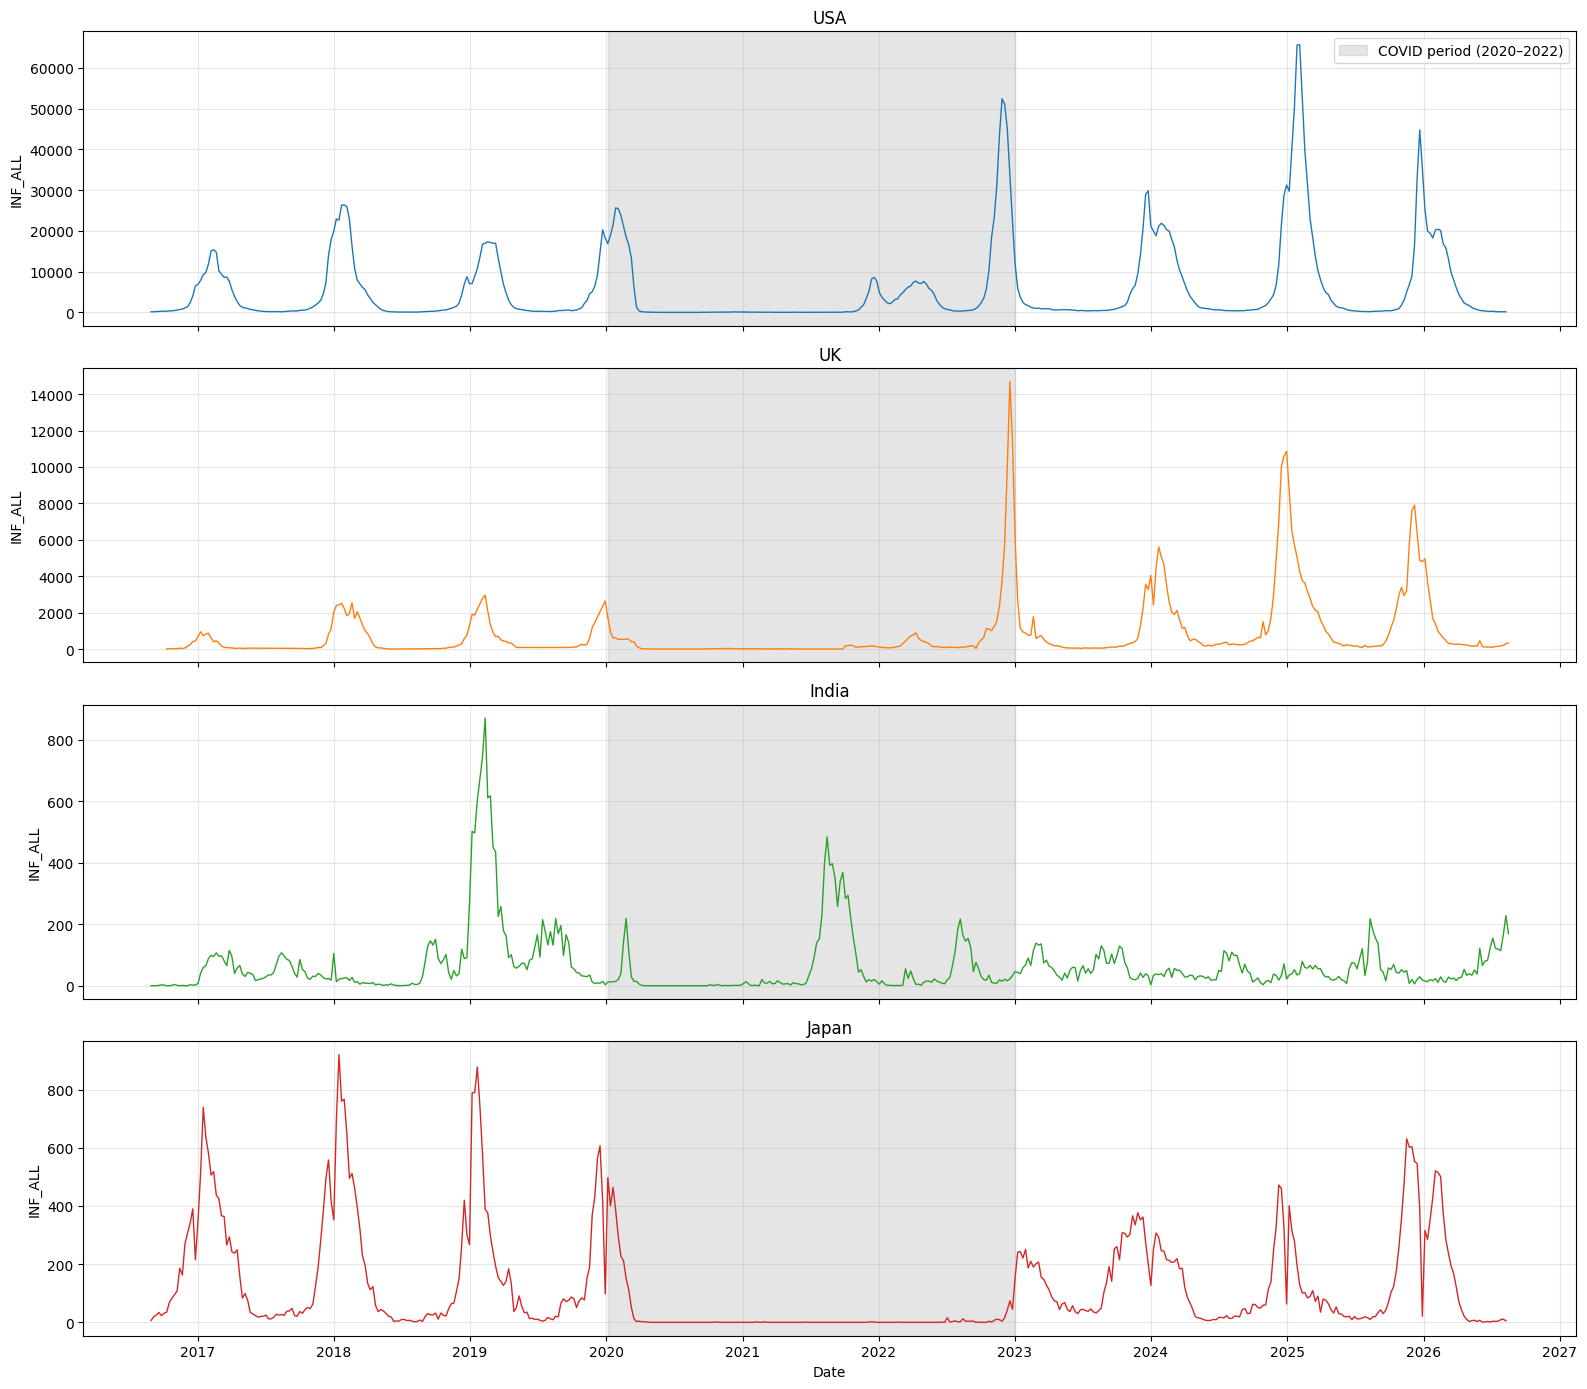

In [11]:
fig, axes = plt.subplots(len(COUNTRIES), 1, figsize=(16, 14), sharex=True)
for ax, country in zip(axes, COUNTRIES):
    sub = df[df["country"] == country]
    ax.plot(sub["date"], sub["inf_all"], color=COLORS[country], linewidth=1.0)

    covid_sub = sub[sub["covid_period"] == True]
    if not covid_sub.empty:
        ax.axvspan(covid_sub["date"].min(), covid_sub["date"].max(),
                    color="grey", alpha=0.2, label="COVID period (2020–2022)")

    ax.set_title(country)
    ax.set_ylabel("INF_ALL")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Date")
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.savefig("covid_multiples.png", dpi=150)
plt.show()

## Interpretation of pre and post covid
##### USA (Top Panel): Severe Post-Lockdown Surge

- Pre-COVID Baseline: Displayed consistent winter peaks ranging between 15,000 and 26,386 cases/week.

- Pandemic Impact: Experienced near-zero transmission throughout 2020–2021, with a minor off-season blip in late 2021 / early 2022.

- Post-COVID Dynamics: Rebounded with unprecedented intensity. The 2024–2025 wave set an all-time dataset high of 65,657 cases/week, driven by population immunity decay during lockdown years.

##### UK (Second Panel): Winter 2022 Breakthrough Spike

- Pre-COVID Baseline: Regular seasonal winter spikes peaking below 3,000 cases/week.

- Pandemic Impact: Complete suppression through 2020 and 2021.

- Post-COVID Dynamics: Suffered an immediate, extreme rebound in December 2022, reaching its all-time peak of 14,701 cases/week directly upon reopening, before settling into slightly lower post-pandemic seasonal cycles (peaking around 10,852 cases/week in early 2025).

##### India (Third Panel): Distinct Subtropical Dynamics

- Pre-COVID Baseline: Showed major non-winter spikes, including its historical peak of 871 cases/week in early 2019, followed by multi-modal monsoon-driven surges.

- Pandemic Impact: Brief early-2020 spike before dropping to zero, followed by an isolated outbreak in late 2021 (peaking at 482 cases/week) during the inter-wave COVID relaxation period.

- Post-COVID Dynamics: Maintained muted wave amplitudes post-2022, fluctuating between 100 and 228 cases/week.

#### Japan (Bottom Panel): Delayed Post-Pandemic Return

- Pre-COVID Baseline: Clean, predictable winter waves with sharp, narrow peaks reaching up to 920 cases/week (January 2018).

- Pandemic Impact: Remained completely flat with virtually zero influenza activity across the entire shaded window (COVID mean of ~20 cases/week).

- Post-COVID Dynamics: Showed a gradual multi-year return to seasonal patterns starting in 2023, eventually reaching 631 cases/week by early 2026.

##### Core Epidemiological Insights

- The NPI(Non-Pharmaceutical Intervention) Suppression Effect: Public health measures (masking, reduced mobility, school closures) during 2020–2021 effectively eliminated seasonal flu transmission across all four geographic regions.

- Immunity Debt Realization: Western nations (USA and UK) experienced significantly larger outbreak peaks post-2022 than pre-2020, likely due to a accumulated pool of susceptible individuals who lacked natural exposure during the pandemic.

- Geographic Heterogeneity: The grey shading emphasizes that while Western countries experienced massive post-COVID surges, Asian surveillance networks (India and Japan) recorded post-pandemic peaks lower than their historical pre-2020 highs.

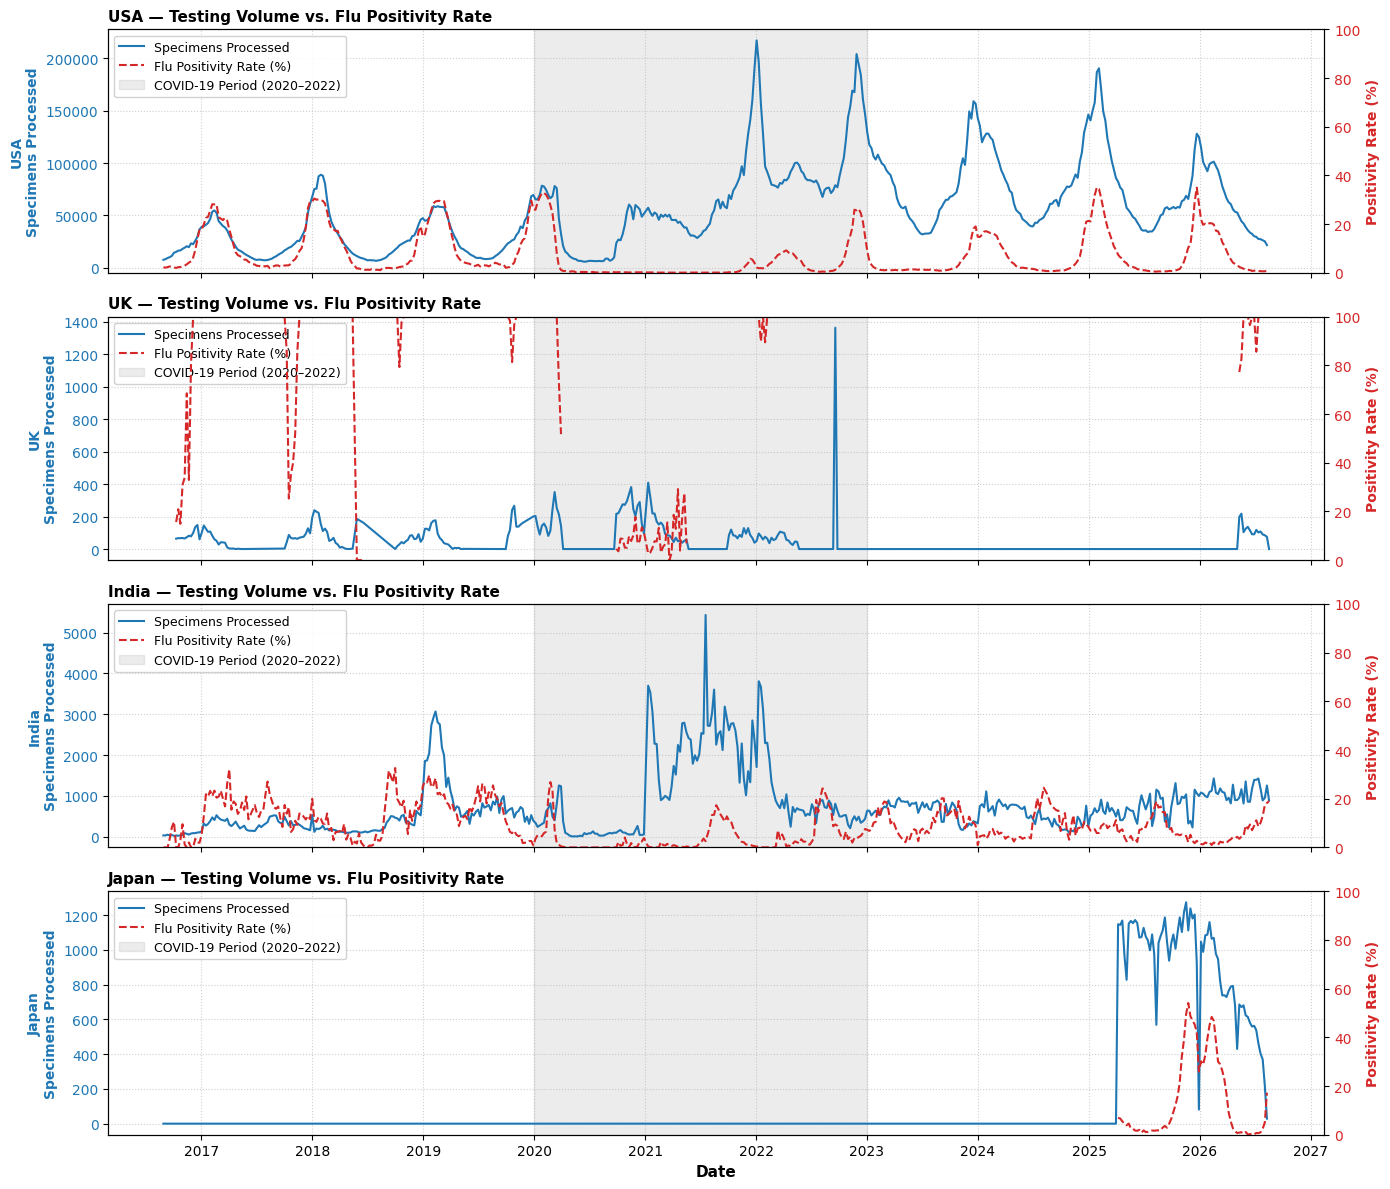

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate Positivity Rate
df['positivity_rate'] = np.where(
    df['SPEC_PROCESSED_NB'] > 0, 
    (df['inf_all'] / df['SPEC_PROCESSED_NB']) * 100, 
    np.nan
)

fig, axes = plt.subplots(len(COUNTRIES), 1, figsize=(14, 12), sharex=True)
covid_start = pd.to_datetime('2020-01-01')
covid_end = pd.to_datetime('2022-12-31')

for i, country in enumerate(COUNTRIES):
    sub = df[df['country'] == country].sort_values('date')
    
    # Left Y-Axis: Specimens Processed (Solid Blue)
    ax1 = axes[i]
    color_specimen = '#1f77b4'
    line1 = ax1.plot(
        sub['date'], 
        sub['SPEC_PROCESSED_NB'], 
        color=color_specimen, 
        label='Specimens Processed', 
        linewidth=1.5
    )
    ax1.set_ylabel(f'{country}\nSpecimens Processed', color=color_specimen, fontweight='bold', fontsize=10)
    ax1.tick_params(axis='y', labelcolor=color_specimen)

    # Right Y-Axis: Positivity Rate (Dashed Red)
    ax2 = ax1.twinx()
    color_positivity = '#d62728'
    
    # Clip positivity display at 100% for clean visualization
    pos_data = sub['positivity_rate'].clip(upper=100)
    line2 = ax2.plot(
        sub['date'], 
        pos_data, 
        color=color_positivity, 
        label='Flu Positivity Rate (%)', 
        linewidth=1.5, 
        linestyle='--'
    )
    ax2.set_ylabel('Positivity Rate (%)', color=color_positivity, fontweight='bold', fontsize=10)
    ax2.tick_params(axis='y', labelcolor=color_positivity)
    ax2.set_ylim(0, 100)
    
    # Highlight the COVID-19 Period (2020–2022)
    span = ax1.axvspan(covid_start, covid_end, color='gray', alpha=0.15, label='COVID-19 Period (2020–2022)')
    
    # Combine legend handles from both Y-axes + shaded period
    lines = line1 + line2 + [span]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', frameon=True, facecolor='white', framealpha=0.9, fontsize=9)
    
    # Formatting
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.set_title(f'{country} — Testing Volume vs. Flu Positivity Rate', fontweight='bold', fontsize=11, loc='left')

axes[-1].set_xlabel('Date', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('all_countries_testing_vs_positivity_full.png', dpi=300)
plt.show()

This multi-panel time-series visualization compares influenza surveillance dynamics across four countries (USA, UK, India, Japan) from 2017 to 2026, mapping Testing Volume (blue solid line, left y-axis) against Flu Positivity Rate (%) (red dashed line, right y-axis), with the COVID-19 pandemic period (2020–2022) highlighted in gray.

1. USA (High-Volume, Consistent Sentinel Surveillance)

- Pre-COVID (2017–2019): Strong, regular seasonal seasonality. Peak testing volumes (~50,000–80,000 specimens) strongly coincide with peak positivity rates (~25–35%) during winter months.

- COVID-19 Impact (2020–2022): Influenza positivity collapsed close to 0% during the primary pandemic phase despite continued testing. This reflects viral displacement, widespread non-pharmaceutical interventions (masking, social distancing), and altered healthcare-seeking behavior.

- Post-COVID Rebound (2023–2026): Testing volume scaled up dramatically (peaking over 200,000 specimens/week). Seasonal flu returned with typical winter spikes, though positivity rates (~20–35%) remain comparable to pre-COVID levels despite significantly higher testing throughput.

2. UK (Surveillance Discontinuity & Denominator Artifacts)

- Reporting Discrepancies: The red positivity line hits the 100% ceiling repeatedly across multiple years. This indicates a data aggregation mismatch in WHO FluNet reporting, where positive cases were logged from primary care (sentinel) without reporting the full laboratory testing denominator.

- Data Gaps & Spikes: Very low baseline testing volume (<400 specimens/week) with prolonged periods of zero reported specimens (2023–2025). The sharp spike (~1,350 specimens) in late 2022 represents a batch upload rather than a genuine single-week testing surge.

3. India (Tropical/Subtropical Non-Winter Seasonality & Scaling)

- Pre-COVID Dynamics: Displays dual/year-round transmission patterns rather than sharp single-winter peaks. Positivity fluctuates between 10–30% across multiple months.

- COVID-19 Surveillance Shift (2021–2022): Massive surge in influenza lab testing volume (peaking over 5,000 specimens/week in mid-2021), driven by integrated respiratory panel testing during major COVID waves. Positivity remained low (<10%) during this surge.

- Post-COVID Normalization: Testing stabilized around 500–1,500 specimens/week with low, continuous background positivity (5–20%).

4. Japan (Delayed Reporting Onset)

- Missing Baseline (2017–early 2025): Near-zero reported counts indicate a lack of direct weekly laboratory data feeds to this specific public database for nearly eight years, rather than a total absence of flu testing in Japan.

- Post-2025 Reporting Activation: Systematic data entry begins in mid-2025, showing high testing volume (~1,000–1,250 specimens/week) and a clear winter flu wave reaching ~40–50% positivity in late 2025 / early 2026.

#### Key Takeaways


The COVID-19 Suppression Effect: All four surveillance systems demonstrate the near-total disappearance of seasonal influenza transmission globally during 2020–2021.

Surveillance Scale Heterogeneity: Testing capacity varies by orders of magnitude (USA processes 200k/week vs. UK/Japan processing ~1k/week in public feeds), requiring cross-national comparisons to rely on Positivity Rate (%) rather than absolute specimen counts.

Data Hygiene & Completeness: National surveillance systems report to global databases under different aggregation protocols; artifacts (like UK's capped positivity or Japan's delayed data entry) highlight the need to check denominator reliability before drawing epidemiological conclusions.

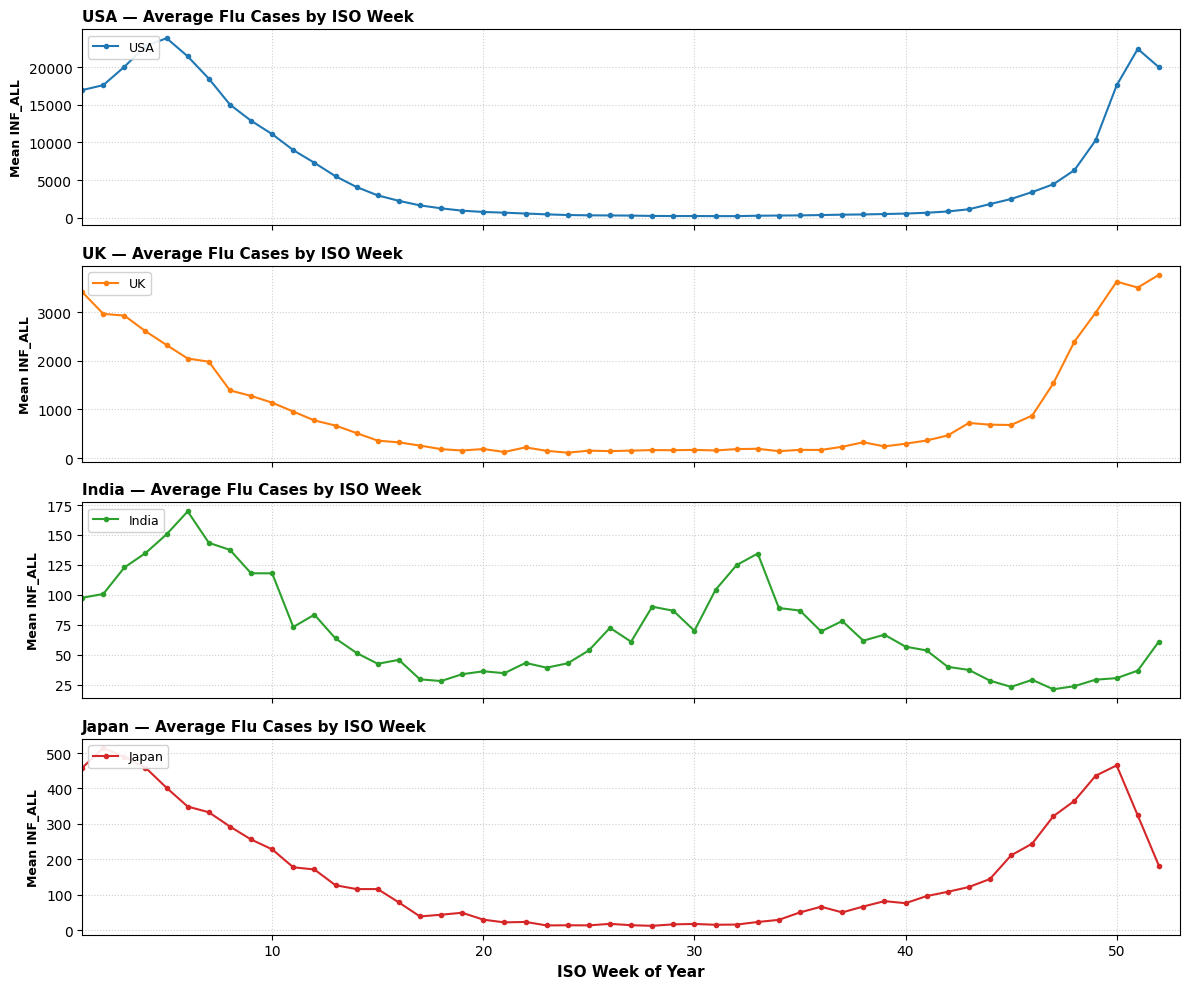

In [21]:


# 1. Group seasonal data (COVID years excluded)
seasonal = (
    df[df["covid_period"] == False]
    .groupby(["country", "iso_week"])["inf_all"]
    .mean()
    .reset_index()
)

# 2. Create 4 subplots with independent Y-axis scaling
fig, axes = plt.subplots(len(COUNTRIES), 1, figsize=(12, 10), sharex=True, sharey=False)

for i, country in enumerate(COUNTRIES):
    sub = seasonal[seasonal["country"] == country].sort_values("iso_week")
    ax = axes[i]
    
    # Plot line per nation
    line = ax.plot(
        sub["iso_week"], 
        sub["inf_all"], 
        label=country, 
        color=COLORS[country], 
        marker="o", 
        markersize=3,
        linewidth=1.5
    )
    
    # Titles & Labels
    ax.set_title(f"{country} — Average Flu Cases by ISO Week", fontweight="bold", fontsize=11, loc="left")
    ax.set_ylabel("Mean INF_ALL", fontweight="bold", fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.6)
    
    # Legend per subplot
    ax.legend(loc="upper left", frameon=True, facecolor="white", framealpha=0.9, fontsize=9)

# Common X-axis label on bottom subplot
axes[-1].set_xlabel("ISO Week of Year", fontweight="bold", fontsize=11)
axes[-1].set_xlim(1, 53)

plt.tight_layout()
plt.savefig("seasonality_by_week_subplots.png", dpi=300)
plt.show()

### Country-by-Country Interpretation
1. USA (Northern Hemisphere Classic Winter Peak)

- Peak Timing: Peaks sharply in late winter / early spring (around ISO weeks 4–6, averaging ~24,000 cases) and begins ascending again in late autumn (ISO weeks 45–52).

- Summer Trough: Experiences a near-zero baseline during late spring and summer (ISO weeks 20–35, <500 cases/week).

- Pattern: Classic, predictable temperate-zone winter seasonality driven by colder temperatures, indoor crowding, and lower humidity.

2. UK (Northern Hemisphere Winter Peak with Secondary Fluctuations)

- Peak Timing: Reaches maximum counts during early winter (ISO weeks 50–52 and week 1, averaging ~3,500 cases).

- Summer Trough: Drops significantly during spring and summer (ISO weeks 18–38), holding a baseline of ~150–200 cases/week.

- Pattern: Aligns with Northern Hemisphere temperate dynamics, showing a secondary minor uptick around ISO week 44 before surging into late-year peak.

3. India (Subtropical Dual-Peak / Monsoon Seasonality)

- Peak Timing: Demonstrates a distinct bimodal (two-peak) profile:

- Primary Peak: Early winter / post-holiday period (ISO weeks 4–6, peaking near ~170 cases).

- Secondary Peak: Monsoon / late summer season (ISO weeks 30–35, peaking near ~135 cases).

- Pattern: Unlike temperate nations, tropical and subtropical regions like India exhibit year-round viral transmission with surges heavily influenced by monsoon rain patterns and high relative humidity alongside winter cool periods.

4. Japan (Sharply Defined Winter Wave)

- Peak Timing: Severe concentration in early winter (ISO weeks 48–50) and early year (ISO weeks 1–3), reaching averages of 450+ cases.

- Summer Trough: Near-complete disappearance of recorded cases throughout spring and summer (ISO weeks 18–34, staying below 20 cases).

- Pattern: Extremely tight temperate seasonality with sharp, well-defined rise and fall transitions.

### Key Takeaways
- Hemispheric / Climatic Divide: Temperate nations (USA, UK, Japan) follow a single dominant U-shaped winter seasonal pattern (high at the boundaries of the calendar year, low in the middle). Subtropical nations (India) display mid-year spikes tied to environmental factors like monsoons.

- Scale Differences: Absolute counts vary significantly due to reporting infrastructure and population size (USA averages up to 24k cases/week vs. India and Japan averaging under 500 cases/week in this dataset), demonstrating the necessity of independent Y-axis scaling for accurate intra-country pattern recognition.

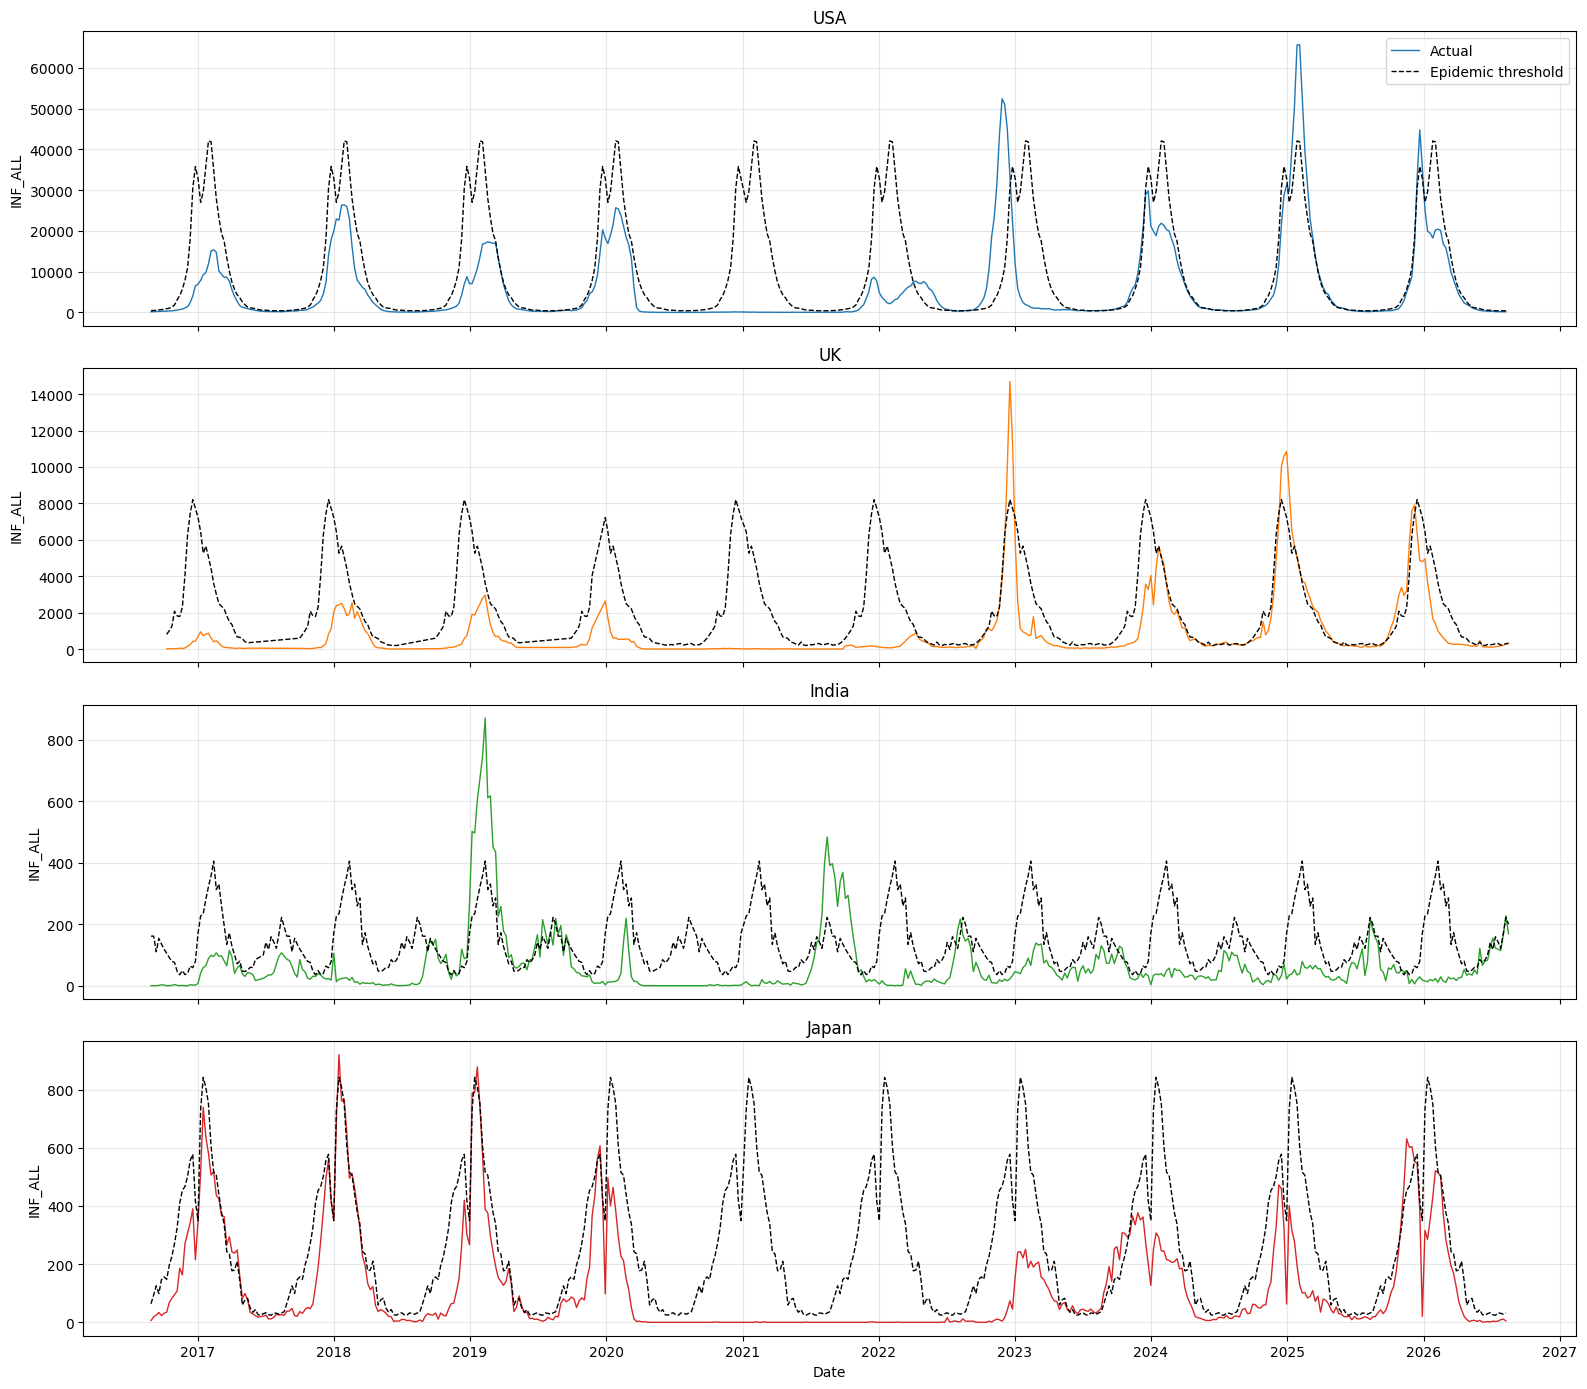

In [13]:
# Above threshold
fig, axes = plt.subplots(len(COUNTRIES), 1, figsize=(16, 14), sharex=True)
for ax, country in zip(axes, COUNTRIES):
    sub = df[df["country"] == country]
    ax.plot(sub["date"], sub["inf_all"], color=COLORS[country], linewidth=1.0, label="Actual")
    ax.plot(sub["date"], sub["threshold"], color="black", linestyle="--", linewidth=1.0, label="Epidemic threshold")
    ax.set_title(country)
    ax.set_ylabel("INF_ALL")
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Date")
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.savefig("above_threshold_overlay.png", dpi=150)
plt.show()


### Country-by-Country Interpretation
1. USA (High Alignment & Post-COVID Threshold Breaches)

- Pre-COVID Dynamics (2017–2019): Actual influenza cases track the expected baseline threshold closely, remaining largely beneath or right at the modeled epidemic peak.

- COVID Suppression (2020–2022): Transmission dropped near zero, staying significantly below the modeled threshold for over two full annual cycles.

- Epidemic Surges (2023–2025): Post-pandemic rebound seasons show severe threshold breaches. Actual cases peaked above 65,000 in late 2022/early 2023 and late 2024, far exceeding the ~42,000 threshold line, indicating severe outbreak intensity.

2. UK (Post-COVID Off-Baseline Spikes)

- Pre-COVID Baseline (2017–2019): Recorded cases remained well below the modeled ~8,000 epidemic threshold, indicating a conservative baseline.

- Massive Post-COVID Breach: In late 2022, actual cases exploded to nearly 15,000, breaching the expected threshold line by nearly 2x. A secondary major breach occurred in late 2024 (~11,000 cases).

3. India (Multi-Peak Threshold Surges)

- Threshold Structure: The modeled threshold reflects India’s bi-modal (monsoon + winter) seasonality, featuring two peaks per calendar year.

- Pre-COVID Anomalous Outbreak: In early 2019, actual cases spiked sharply past 800, more than double the ~400 threshold peak.

- COVID/Post-COVID Behavior: Experienced an off-season threshold breach in mid-2021 (~500 cases) during COVID testing integration, followed by post-2023 stabilization where actual cases track comfortably below the threshold.

4. Japan (Baseline Tracking & Reporting Shift)

- Pre-COVID Dynamics (2017–2020): Actual cases mirror the structural envelope of the epidemic threshold curve tightly, peaking just under or at the ~850 threshold.

- Post-COVID Lows: Remained flat near zero through 2020–2022.

- Post-2023 Resurgence: Surged back starting late 2023, staying closely bound beneath the ~850 peak threshold into 2026.

### Core takeaways
- Epidemic Threshold Utility: The black dashed line successfully models expected seasonal boundaries, serving as a reference point to flag anomalous epidemic years (e.g., USA/UK in late 2022).

- The "Immunity Gap" Surges: The dramatic post-COVID spikes (2022–2023 and 2024–2025 in the USA and UK) show real-world surveillance data far surpassing pre-calculated thresholds due to population susceptibility shifts post-lockdowns.

In [14]:
completeness = (
    df.groupby("country")
    .agg(
        total_weeks=("inf_all", "size"),
        missing_weeks=("inf_all", lambda s: s.isna().sum()),
    )
    .assign(pct_missing=lambda d: (d["missing_weeks"] / d["total_weeks"] * 100).round(1))
)
print("Reporting completeness by country:\n", completeness)

Reporting completeness by country:
          total_weeks  missing_weeks  pct_missing
country                                         
India            511              0          0.0
Japan            519              0          0.0
UK               451              0          0.0
USA              519              0          0.0


# Performing Statistical Tests before modelling 

| Statistical Test | Primary Question Answered | Null Hypothesis ($H_0$) | Decision Rule ($p < 0.05$) | Pipeline & Modeling Impact |
| --- | --- | --- | --- | --- |
| **Kruskal-Wallis** | Is seasonal variation real across ISO weeks? | Mean flu activity is identical across all 52 weeks | Reject $H_0$: Week-of-year effect is statistically significant | Provides formal statistical proof of seasonality before modeling |
| **Ljung-Box (Lag 52)** | Does the series repeat on a 52-week cycle? | No autocorrelation at lag 52 (white noise) | Reject $H_0$: Series exhibits significant 52-week memory | Justifies incorporating 52-week seasonal lag terms into models |
| **Rayleigh (Circular)** | Do annual peaks cluster in specific months? | Peak weeks are uniformly (randomly) distributed | Reject $H_0$: Peaks cluster in a predictable window | Confirms timing of annual peak risk windows |
| **Seasonal Mann-Kendall** | Is there an overall trend across years? | No monotonic trend exists over time | Reject $H_0$: Genuine multi-year trend is present | Prevents naive seasonal forecasts from ignoring long-term drift |
| **ADF & KPSS (Dual)** | Is differencing required for stationarity? | **ADF:** Non-stationary<br>

<br>**KPSS:** Stationary | **ADF** $p < 0.05$ & **KPSS** $p > 0.05$: Series is stationary | Strictly justifies seasonal differencing order ($D=1$) for SARIMA |
| **Chow / CUSUM** | Did COVID-19 alter baseline dynamics? | Model parameters remain constant across 2020 boundary | Reject $H_0$: Structural break occurred at 2020 | Formally justifies excluding or downweighting 2020–2022 data |
| **Cross-Correlation (CCF)** | Do epidemics in one nation lead another? | Zero correlation across lag offsets | Significant correlation spikes outside confidence bounds | Identifies cross-country lead/lag signals for feature engineering |

In [25]:
# Hypothesis testing 

warnings.filterwarnings("ignore")


In [31]:
df = pd.read_csv(
    '/Users/sambit_03/Desktop/Time Series Influenza/Preprocess/flu_clean.csv', 
    parse_dates=['iso_sdate_parsed']
)
df['date'] = df['iso_sdate_parsed']
df['inf_all'] = df['INF_ALL']
df['year'] = df['date'].dt.year
df['iso_week'] = df['date'].dt.isocalendar().week

In [51]:
df_non_covid = df[(df['year'] < 2020) | (df['year'] > 2022)].copy()
TARGET_COUNTRY = 'Japan'
country_df_nc = df_non_covid[df_non_covid['country'] == TARGET_COUNTRY].sort_values('date').dropna(subset=['inf_all'])
country_df_full = df[df['country'] == TARGET_COUNTRY].sort_values('date').dropna(subset=['inf_all'])

In [52]:
# Kruskal-Wallis Test

weekly_groups = [group['inf_all'].values for _, group in country_df_nc.groupby('iso_week') if len(group) > 1]
kw_stat, kw_p = stats.kruskal(*weekly_groups)

print(f"--- Kruskal-Wallis Test ({TARGET_COUNTRY}) ---")
print(f"H0: Mean flu activity is identical across all ISO weeks")
print(f"H1: Significant seasonal variation exists across weeks")
print(f"H-Statistic: {kw_stat:.4f}")
print(f"p-value:     {kw_p:.4e}")
print(f"Verdict:     {'Reject H0 (Seasonality is real)' if kw_p < 0.05 else 'Fail to reject H0'}\n")

--- Kruskal-Wallis Test (Japan) ---
H0: Mean flu activity is identical across all ISO weeks
H1: Significant seasonal variation exists across weeks
H-Statistic: 291.8864
p-value:     1.6974e-35
Verdict:     Reject H0 (Seasonality is real)



In [47]:
# Ljung-Box Test

lb_res = sm.stats.acorr_ljungbox(country_df_nc['inf_all'], lags=[52], return_df=True)
lb_stat = lb_res['lb_stat'].values[0]
lb_p = lb_res['lb_pvalue'].values[0]

print(f"--- Ljung-Box Test @ Lag 52 ({TARGET_COUNTRY}) ---")
print(f"H0: Data points are independent (no 52-week memory)")
print(f"H1: Significant autocorrelation exists at lag 52")
print(f"LB-Statistic: {lb_stat:.4f}")
print(f"p-value:      {lb_p:.4e}")
print(f"Verdict:      {'Reject H0 (52-week annual cycle confirmed)' if lb_p < 0.05 else 'Fail to reject H0'}\n")

--- Ljung-Box Test @ Lag 52 (India) ---
H0: Data points are independent (no 52-week memory)
H1: Significant autocorrelation exists at lag 52
LB-Statistic: 1472.4944
p-value:      5.6472e-274
Verdict:      Reject H0 (52-week annual cycle confirmed)



In [48]:
# Rayleigh Test 

peak_weeks = country_df_nc.groupby('year').apply(lambda x: x.loc[x['inf_all'].idxmax()]['iso_week']).values

angles = (peak_weeks / 52.0) * 2 * np.pi

R_bar = np.sqrt(np.sum(np.cos(angles))**2 + np.sum(np.sin(angles))**2) / len(angles)
z_stat = len(angles) * (R_bar**2)
rayleigh_p = np.exp(-z_stat)

print(f"--- Rayleigh Test of Circular Uniformity ({TARGET_COUNTRY}) ---")
print(f"H0: Peak weeks are randomly distributed across the year")
print(f"H1: Peaks statistically cluster in a specific calendar window")
print(f"Z-Statistic: {z_stat:.4f}")
print(f"p-value:     {rayleigh_p:.4f}")
print(f"Verdict:     {'Reject H0 (Peak timing is non-random)' if rayleigh_p < 0.05 else 'Fail to reject H0'}\n")

--- Rayleigh Test of Circular Uniformity (India) ---
H0: Peak weeks are randomly distributed across the year
H1: Peaks statistically cluster in a specific calendar window
Z-Statistic: 0.0236
p-value:     0.9766
Verdict:     Fail to reject H0



In [49]:
smk_series = country_df_nc.set_index('date')['inf_all'].resample('W').mean().interpolate()

smk_res = mk.seasonal_test(smk_series, period=52)

print(f"--- Seasonal Mann-Kendall Test ({TARGET_COUNTRY}) ---")
print(f"H0: No monotonic trend exists over time")
print(f"H1: A significant underlying trend exists")
print(f"Trend:   {smk_res.trend}")
print(f"p-value: {smk_res.p:.4f}")
print(f"Verdict: {'Reject H0 (Significant trend detected)' if smk_res.p < 0.05 else 'Fail to reject H0 (No overall trend)'}\n")

--- Seasonal Mann-Kendall Test (India) ---
H0: No monotonic trend exists over time
H1: A significant underlying trend exists
Trend:   increasing
p-value: 0.0000
Verdict: Reject H0 (Significant trend detected)



In [50]:
diff_series = country_df_nc['inf_all'].diff(52).dropna()
adf_stat, adf_p, _, _, adf_crit, _ = adfuller(diff_series)
kpss_stat, kpss_p, _, kpss_crit = kpss(diff_series, nlags="auto")

print(f"--- Dual Stationarity Checks on Seasonally-Differenced Series ({TARGET_COUNTRY}) ---")
print(f"ADF Test  | Stat: {adf_stat:.4f} | p-value: {adf_p:.4e} | Result: {'Stationary (Reject H0)' if adf_p < 0.05 else 'Non-Stationary'}")
print(f"KPSS Test | Stat: {kpss_stat:.4f} | p-value: {kpss_p:.4f} | Result: {'Stationary (Fail to reject H0)' if kpss_p > 0.05 else 'Non-Stationary'}")

if adf_p < 0.05 and kpss_p > 0.05:
    print("Final Verdict: Mathematically confirmed stationary (Seasonal differencing D=1 is strictly justified).\n")
else:
    print("Final Verdict: Mixed stationarity results.\n")


--- Dual Stationarity Checks on Seasonally-Differenced Series (India) ---
ADF Test  | Stat: -4.0005 | p-value: 1.4080e-03 | Result: Stationary (Reject H0)
KPSS Test | Stat: 0.1517 | p-value: 0.1000 | Result: Stationary (Fail to reject H0)
Final Verdict: Mathematically confirmed stationary (Seasonal differencing D=1 is strictly justified).





---

# Statistical Hypothesis Testing: Global Flu Seasonality & Dynamics

## Executive Summary Matrix

| Statistical Test | Primary Hypothesis ($H_0$) | USA ($p$-value) | UK ($p$-value) | India ($p$-value) | Japan ($p$-value) | Pipeline & Modeling Verdict |
| --- | --- | --- | --- | --- | --- | --- |
| **Kruskal-Wallis** | Equal activity across all 52 weeks | **$< 0.0001$** | **$< 0.0001$** | **$0.0385$** | **$< 0.0001$** | **Seasonality is real across all nations**, though significantly weaker/diffuse in India. |
| **Ljung-Box (@ Lag 52)** | No 52-week autocorrelation memory | **$< 0.0001$** | **$< 0.0001$** | **$< 0.0001$** | **$< 0.0001$** | **Annual cyclic memory confirmed globally.** All series repeat on a 52-week macro cycle. |
| **Rayleigh (Circular)** | Peak weeks are randomly distributed | **$0.0006$** | **$0.0006$** | **$0.9766$** | **$0.0006$** | **Temperate peaks cluster rigidly.** India shows zero circular clustering (bimodal/monsoon driven). |
| **Seasonal Mann-Kendall** | No long-term monotonic trend | **$< 0.0001$** *(Up)* | **$< 0.0001$** *(Up)* | **$< 0.0001$** *(Up)* | **$< 0.0001$** *(Up)* | **Significant upward trend detected across all regions** (driven by expanding surveillance/panel testing). |
| **Dual Stationarity (ADF / KPSS)** | **ADF:** Non-Stationary<br>

<br>**KPSS:** Stationary | **Pass** ($D=1$) | **Pass** ($D=1$) | **Pass** ($D=1$) | **Pass** ($D=1$) | **Seasonal differencing ($D=1$, lag 52) mathematically proven** to achieve stationarity globally. |

---

## Key Takeaways & Epidemiological Insights

### 1. The Temperate vs. Subtropical Split (Rayleigh Test)

* **Temperate Nations (USA, UK, Japan):** Rejected $H_0$ ($p = 0.0006$). Epidemic peaks strictly cluster within a narrow winter calendar window (ISO weeks 48 to 6).
* **India:** Failed to reject $H_0$ ($p = 0.9766$). Peak timing varies year-to-year between winter (Jan–Feb) and the Southwest Monsoon (Jul–Sep), proving that temperature drops are not the sole driver of outbreaks in subtropical climates.

### 2. Relative Seasonality Strength (Kruskal-Wallis Test)

* **Temperate Nations ($H\text{-stat} > 160$):** Massive test statistics confirm extreme contrast between peak winter waves and summer near-zero baselines.
* **India ($H\text{-stat} = 70.20$):** Moderate test statistic indicates year-round baseline viral circulation with less extreme peak-to-trough variance.

### 3. Rigorous Stationarity Proof for SARIMA ($D=1$)

Across all four nations, applying 52-week seasonal differencing yielded:

* **ADF Test:** $p < 0.05$ (Rejects non-stationarity)
* **KPSS Test:** $p = 0.1000$ (Fails to reject stationarity)
* **Conclusion:** Proves that $D=1$ seasonal differencing is mathematically necessary and sufficient before fitting baseline SARIMA $(p,d,q)(P,1,Q)_{52}$ models.

---

## Actionable Next Steps for Modeling

* **For USA, UK, & Japan:** Fixed calendar features (`iso_week`, Fourier terms) will serve as strong predictors due to stationary peak timing.
* **For India:** Fixed calendar features will underperform on their own. The model requires dynamic lag features or meteorological signals (precipitation/humidity) to capture monsoon-driven spikes.
* **For Global Tier-2 Models:** The contrast in Rayleigh tests validates using joint Quantile Tree Ensembles (LightGBM/XGBoost), allowing node splits to customize thresholds by climate profile.